In [1]:
import numpy as np
import bayesflow as bf
import keras
from pathlib import Path

INFO:matplotlib.font_manager:Failed to extract font properties from /System/Library/Fonts/ZitherTamil.otf: Can not load face (SFNT font table missing; error code 0x8e)
INFO:matplotlib.font_manager:Failed to extract font properties from /System/Library/Fonts/Apple Color Emoji.ttc: Could not set the fontsize (invalid pixel size; error code 0x17)
INFO:matplotlib.font_manager:Failed to extract font properties from /System/Library/Fonts/Supplemental/NISC18030.ttf: Could not set the fontsize (invalid pixel size; error code 0x17)
INFO:matplotlib.font_manager:Failed to extract font properties from /System/Library/Fonts/ZitherMalayalam.otf: Can not load face (SFNT font table missing; error code 0x8e)
INFO:matplotlib.font_manager:Failed to extract font properties from /System/Library/Fonts/LastResort.otf: tuple indices must be integers or slices, not str
INFO:matplotlib.font_manager:Failed to extract font properties from /System/Library/PrivateFrameworks/FontServices.framework/Resources/Reserved

In [2]:
bf.__version__

'2.0.12'

In [3]:
RNG=np.random.default_rng(2025)
num_dims=20
num_obs=100
mu_prior_mean1=0
mu_prior_mean2=3
mu_prior_std=1
likelihood_std1=1
likelihood_std2=3
# student_df=5

In [4]:
def prior_1():
    mu=RNG.normal(loc=mu_prior_mean1,scale=mu_prior_std,size=num_dims)
    return dict(mu=mu)
def prior_2():
    mu=RNG.normal(loc=mu_prior_mean2,scale=mu_prior_std,size=num_dims)
    return dict(mu=mu)
def likelihood_1(mu):
    x=RNG.normal(loc=mu,scale=likelihood_std1,size=(num_obs,num_dims))
    return dict(x=x)
def likelihood_2(mu):
    x=RNG.normal(loc=mu,scale=likelihood_std2,size=(num_obs,num_dims))
    return dict(x=x)

simulator_1=bf.make_simulator([prior_1,likelihood_1])
simulator_2=bf.make_simulator([prior_2,likelihood_1])
simulator_3=bf.make_simulator([prior_1,likelihood_2])
simulator=bf.simulators.ModelComparisonSimulator(
    simulators=[simulator_1,simulator_2,simulator_3],
    use_mixed_batches=True,
    )


In [5]:
data = simulator.sample(100)
for key, value in data.items():
    print(key + " shape:", np.array(value).shape)

mu shape: (100, 20)
x shape: (100, 100, 20)
model_indices shape: (100, 3)


In [6]:
# adapter 
adapter = (bf.Adapter()
           .as_set("x")
           .convert_dtype("float64", "float32")
           .rename('x', 'summary_variables')
           .rename('model_indices', 'inference_variables')
                )

In [27]:
# networks
summary_network = bf.networks.DeepSet(summary_dim=6*num_dims)
classifier_network = bf.networks.MLP()

In [28]:
approximator = bf.approximators.ModelComparisonApproximator(
            num_models=3,
            classifier_network=classifier_network,
            summary_network=summary_network,
            adapter=adapter,
            standardize="all",  
        )

In [29]:
epochs=100
batch_size=100
num_batches_per_epoch=200
learning_rate=keras.optimizers.schedules.CosineDecay(
            initial_learning_rate=1e-4, 
            decay_steps=epochs * num_batches_per_epoch
            )
approximator.compile(optimizer=keras.optimizers.Adam(learning_rate=learning_rate))

In [30]:
history = approximator.fit(simulator=simulator,adapter=adapter,
                           epochs=epochs,batch_size=batch_size,num_batches=num_batches_per_epoch,)

INFO:bayesflow:Building dataset from simulator instance of ModelComparisonSimulator.
INFO:bayesflow:Using 12 data loading workers.
INFO:bayesflow:Building on a test batch.


Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 12s 56ms/step - cross_entropy/inference_cross_entropy: 0.0011 - loss: 0.0011
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 11s 54ms/step - cross_entropy/inference_cross_entropy: 7.2373e-04 - loss: 7.2373e-04
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 11s 56ms/step - cross_entropy/inference_cross_entropy: 1.8021e-04 - loss: 1.8021e-04
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 11s 56ms/step - cross_entropy/inference_cross_entropy: 0.0455 - loss: 0.0455
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 11s 56ms/step - cross_entropy/inference_cross_entropy: 1.8572e-06 - loss: 1.8572e-06
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 11s 56ms/step - cross_entropy/inference_cross_entropy: 3.2384e-06 - loss: 3.2384e-06
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 11s 56ms/step - cross_entropy/inference_cross_entropy: 8.0674e-06 - loss: 8.0674e-06
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 11s 56ms/step - cross_entropy/inference_cross_entropy: 5.5465e-06 - loss: 5.5465e-06
Epoch 9/

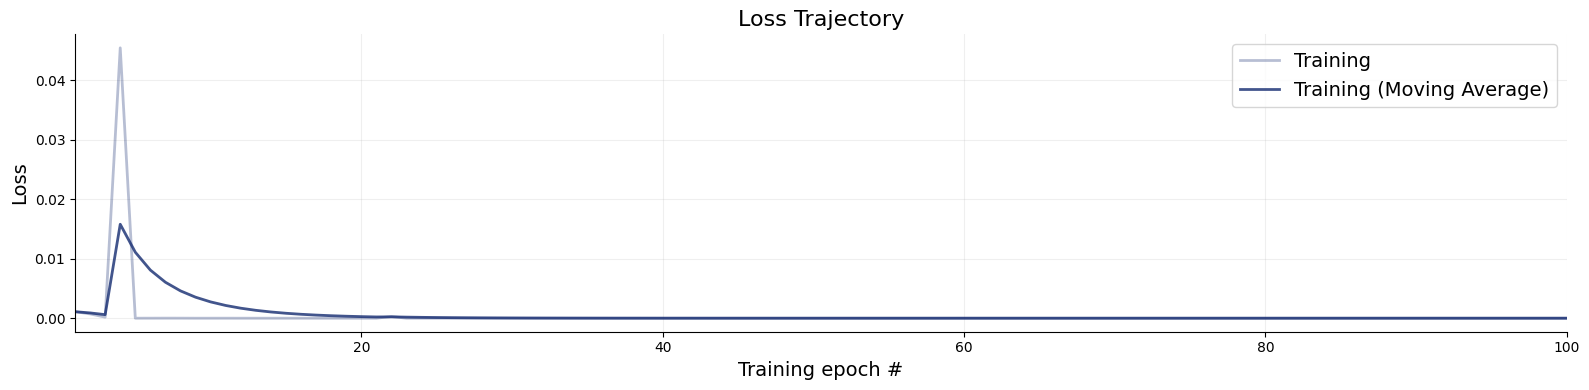

In [31]:
f=bf.diagnostics.plots.loss(history)

In [32]:
val_df=simulator.sample(5000)
pred_models = approximator.predict(conditions=val_df, probs=True)

Summarizing:   0%|          | 0/1 [00:00<?, ?batch/s]

INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode


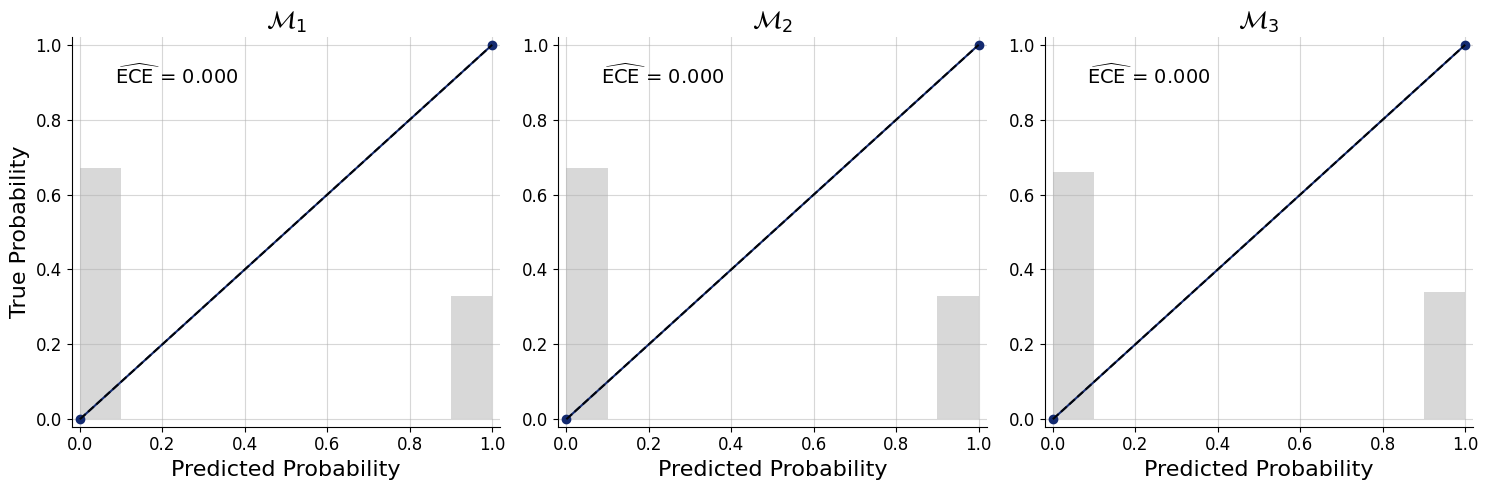

In [33]:
f = bf.diagnostics.plots.mc_calibration(
    pred_models=pred_models,
    true_models=val_df["model_indices"],
    model_names=[r"$\mathcal{M}_1$", r"$\mathcal{M}_2$",r"$\mathcal{M}_3$"],
)

INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode


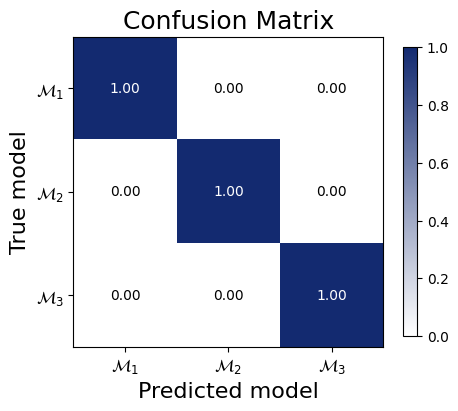

In [34]:
f = bf.diagnostics.plots.mc_confusion_matrix(
    pred_models=pred_models,
    true_models=val_df["model_indices"],
    model_names=[r"$\mathcal{M}_1$", r"$\mathcal{M}_2$",r"$\mathcal{M}_3$"],
    normalize="true",
)

In [35]:
# Save the trained approximator
filepath = Path("/Users/yimingzang/Documents/thesis/benchmark2/benchmark/examples/gaussian/networks") / "direct_s_20d_100n.keras"
filepath.parent.mkdir(exist_ok=True)
approximator.save(filepath=filepath)

Summarizing:   0%|          | 0/1 [00:00<?, ?batch/s]

INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode


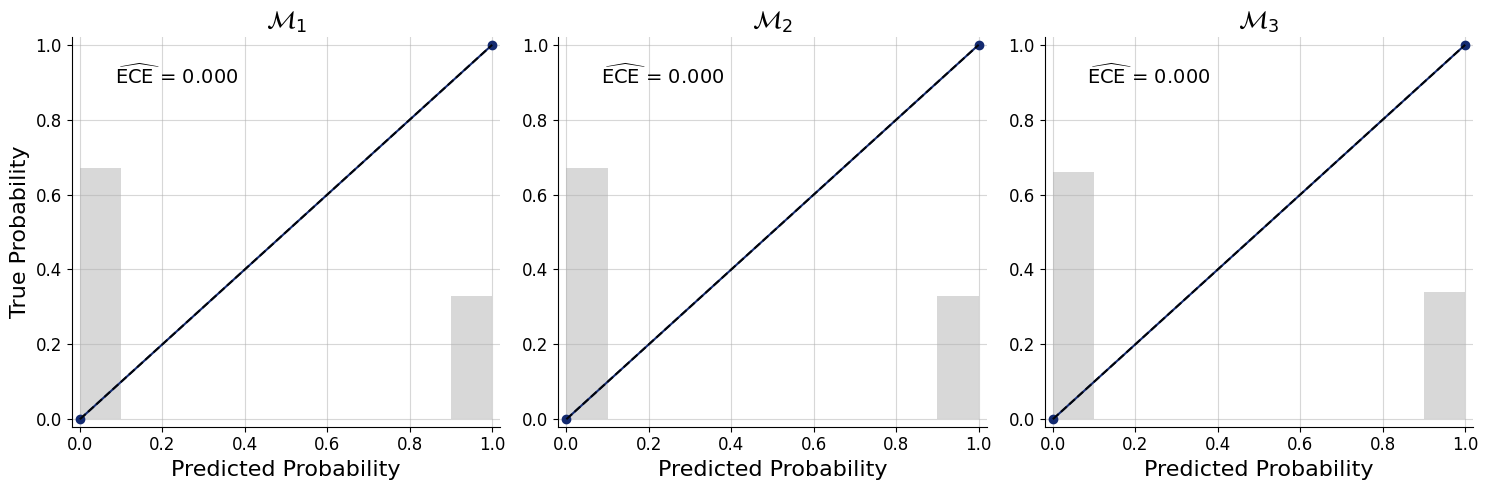

In [36]:
# Load approximator
filepath = Path("/Users/yimingzang/Documents/thesis/benchmark2/benchmark/examples/gaussian/networks") / "direct_s_20d_100n.keras"
approximator = keras.saving.load_model(filepath)
pred_models = approximator.predict(conditions=val_df, probs=True)
f = bf.diagnostics.plots.mc_calibration(
    pred_models=pred_models,
    true_models=val_df["model_indices"],
    model_names=[r"$\mathcal{M}_1$", r"$\mathcal{M}_2$",r"$\mathcal{M}_3$"],
)